# Discovering Sparse Relationships Between Real Rate Differentials and EURUSD Multi-Horizon Forward Returns using PySINDy

This notebook treats the real-rate channel as a sparse regression / function discovery problem. The objective is not to estimate a continuous-time ODE, but to discover compact nonlinear equations of the form:

`ret_horizon_fwd = f(real_rate_diff_state, vix, interactions)`

The feature set is deliberately restricted to the real-rate differential state, its standardized regimes and change, VIX, and a real-rate/VIX interaction. Sparse, economically interpretable equations are preferred over high in-sample accuracy.

## 0. Environment

Run this notebook with the `adonys` conda environment. If PySINDy is not already installed in that environment, the first code cell installs it with `pip install pysindy` using the active notebook kernel.

In [1]:
from __future__ import annotations

import subprocess
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree

try:
    import pysindy as ps
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pysindy"])
    import pysindy as ps

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print(f"Python: {sys.executable}")
print(f"PySINDy: {ps.__version__}")

Python: C:\Users\Hermes\miniconda3\envs\adonys\python.exe
PySINDy: 2.1.0


## 1. Data Loading and Preprocessing

The project data builder is used when the CSV needs to be refreshed. Otherwise, the existing daily feature file is loaded. Forward returns are rebuilt explicitly as `ret_1d_fwd`, `ret_5d_fwd`, and `ret_20d_fwd` to keep the target definitions consistent across horizons.

In [2]:
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR
for parent in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents]:
    if (parent / "metalib" / "mtofx_daily_data.py").exists():
        REPO_ROOT = parent
        break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from metalib.mtofx_daily_data import build_eurusd_mtofx_daily_features

DATA_PATH = REPO_ROOT / "metalib" / "data" / "eurusd" / "eurusd_mtofx_daily_features.csv"
OUTPUT_PATH = DATA_PATH
REFRESH_DATA = False
FRED_API_KEY = None  # Uses FRED_API_KEY env var or the project default when None.
DATA_START = "2005-01-01"
DATA_END = None

print(f"Repo root: {REPO_ROOT}")
print(f"Data path: {DATA_PATH}")

Repo root: C:\Users\Hermes\PycharmProjects\metalib
Data path: C:\Users\Hermes\PycharmProjects\metalib\metalib\data\eurusd\eurusd_mtofx_daily_features.csv


In [3]:
if REFRESH_DATA or not DATA_PATH.exists():
    raw = build_eurusd_mtofx_daily_features(
        start=DATA_START,
        end=DATA_END,
        fred_api_key=FRED_API_KEY,
        output_path=OUTPUT_PATH,
    )
else:
    raw = pd.read_csv(DATA_PATH)

df = raw.copy()
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")
else:
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

required_source_cols = ["close", "us_10y_real", "eu_10y_real", "vix"]
missing_source_cols = [col for col in required_source_cols if col not in df.columns]
if missing_source_cols:
    raise ValueError(f"Missing required source columns: {missing_source_cols}")

# Core real-rate state. Positive values mean US real yields exceed euro-area real yields.
df["real_rate_diff"] = df["us_10y_real"] - df["eu_10y_real"]

# Forward returns from today's close to the close h trading days ahead.
for horizon in [1, 5, 20]:
    df[f"ret_{horizon}d_fwd"] = df["close"].pct_change(horizon).shift(-horizon)

# 52w and 156w are approximated with 252 and 756 trading days.
def rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    mean = series.rolling(window, min_periods=window // 2).mean()
    std = series.rolling(window, min_periods=window // 2).std()
    return (series - mean) / std.replace(0, np.nan)

df["real_rate_diff_zscore_52w"] = rolling_zscore(df["real_rate_diff"], 252)
df["real_rate_diff_zscore_156w"] = rolling_zscore(df["real_rate_diff"], 756)
df["real_rate_diff_4w_change"] = df["real_rate_diff"].diff(20)
df["real_rate_diff_x_vix"] = df["real_rate_diff"] * df["vix"]

FEATURE_COLS = [
    "real_rate_diff",
    "real_rate_diff_zscore_52w",
    "real_rate_diff_zscore_156w",
    "real_rate_diff_4w_change",
    "vix",
    "real_rate_diff_x_vix",
]
TARGET_COLS = ["ret_1d_fwd", "ret_5d_fwd", "ret_20d_fwd"]

model_df = df[FEATURE_COLS + TARGET_COLS].replace([np.inf, -np.inf], np.nan).dropna()

print(f"Model sample: {model_df.index.min().date()} to {model_df.index.max().date()}")
print(f"Rows: {len(model_df):,}")
display(model_df.describe().T)

Model sample: 2006-06-14 to 2026-04-06
Rows: 5,141


,count,mean,std,min,25%,50%,75%,max
real_rate_diff,5141.0,4.746513e-01,2.142479,-3.049889,-0.995408,0.294441,1.139948,9.240328
real_rate_diff_zscore_52w,5141.0,9.078826e-03,1.476582,-4.808633,-1.169831,-0.016960,1.217176,6.446535
real_rate_diff_zscore_156w,5141.0,7.748745e-02,1.460098,-4.316911,-0.929667,0.041233,1.235914,3.842829
real_rate_diff_4w_change,5141.0,-2.200609e-03,0.384089,-2.043756,-0.187306,-0.002871,0.204496,1.466572
vix,5141.0,1.959549e+01,8.696088,9.140000,13.860000,17.250000,22.610000,82.690000
real_rate_diff_x_vix,5141.0,9.486241e+00,50.912696,-96.228522,-18.244741,3.881829,18.902812,301.438264
ret_1d_fwd,5141.0,-7.414696e-07,0.005581,-0.026604,-0.003109,0.000034,0.003076,0.034903
ret_5d_fwd,5141.0,1.906796e-06,0.012321,-0.065191,-0.007002,-0.000023,0.007132,0.106059
ret_20d_fwd,5141.0,-9.900618e-07,0.024508,-0.136180,-0.013785,-0.000377,0.014650,0.152437


## 2. Exploratory Analysis

The diagnostics below are intentionally narrow: correlations and scatter plots between the real-rate state variables and the three forward return horizons.

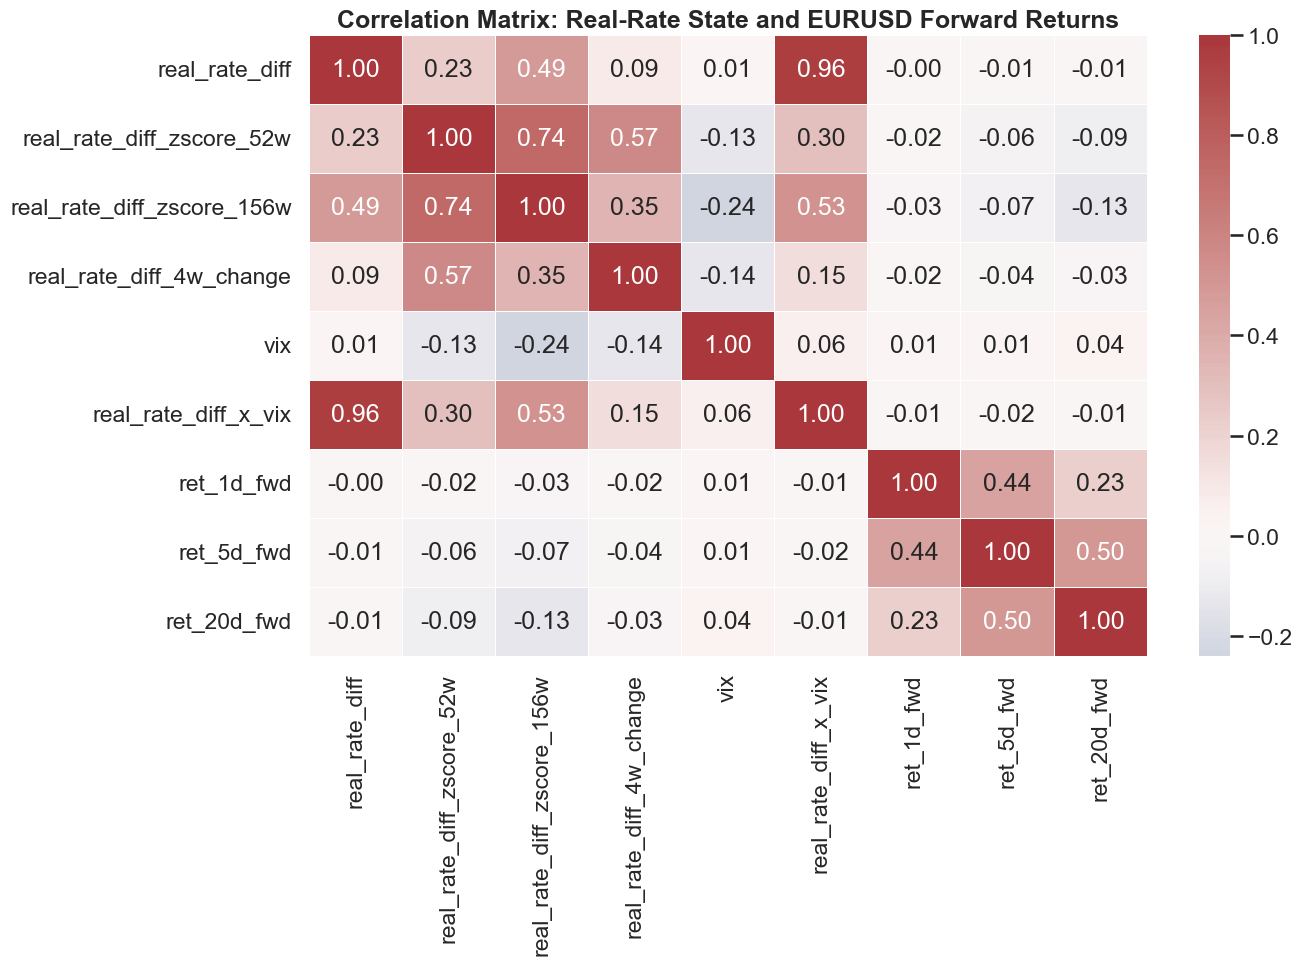

,ret_1d_fwd,ret_5d_fwd,ret_20d_fwd
vix,0.005,0.008,0.036
real_rate_diff,-0.005,-0.011,-0.010
real_rate_diff_x_vix,-0.009,-0.016,-0.014
real_rate_diff_4w_change,-0.018,-0.038,-0.035
real_rate_diff_zscore_52w,-0.025,-0.058,-0.088
real_rate_diff_zscore_156w,-0.031,-0.072,-0.130


In [4]:
corr = model_df[FEATURE_COLS + TARGET_COLS].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Real-Rate State and EURUSD Forward Returns")
plt.tight_layout()
plt.show()

target_corr = corr.loc[FEATURE_COLS, TARGET_COLS].sort_values("ret_20d_fwd", ascending=False)
display(target_corr.style.background_gradient(cmap="vlag", axis=None, vmin=-0.25, vmax=0.25).format("{:.3f}"))

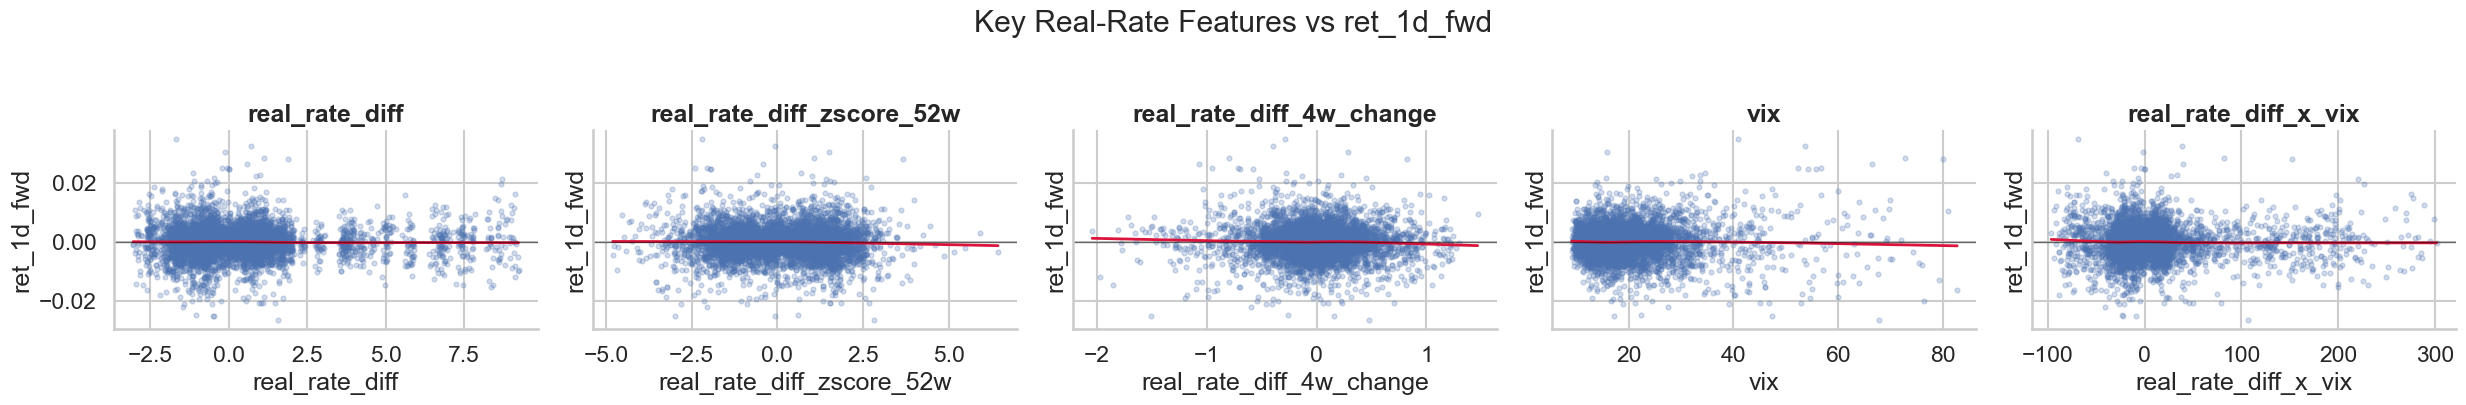

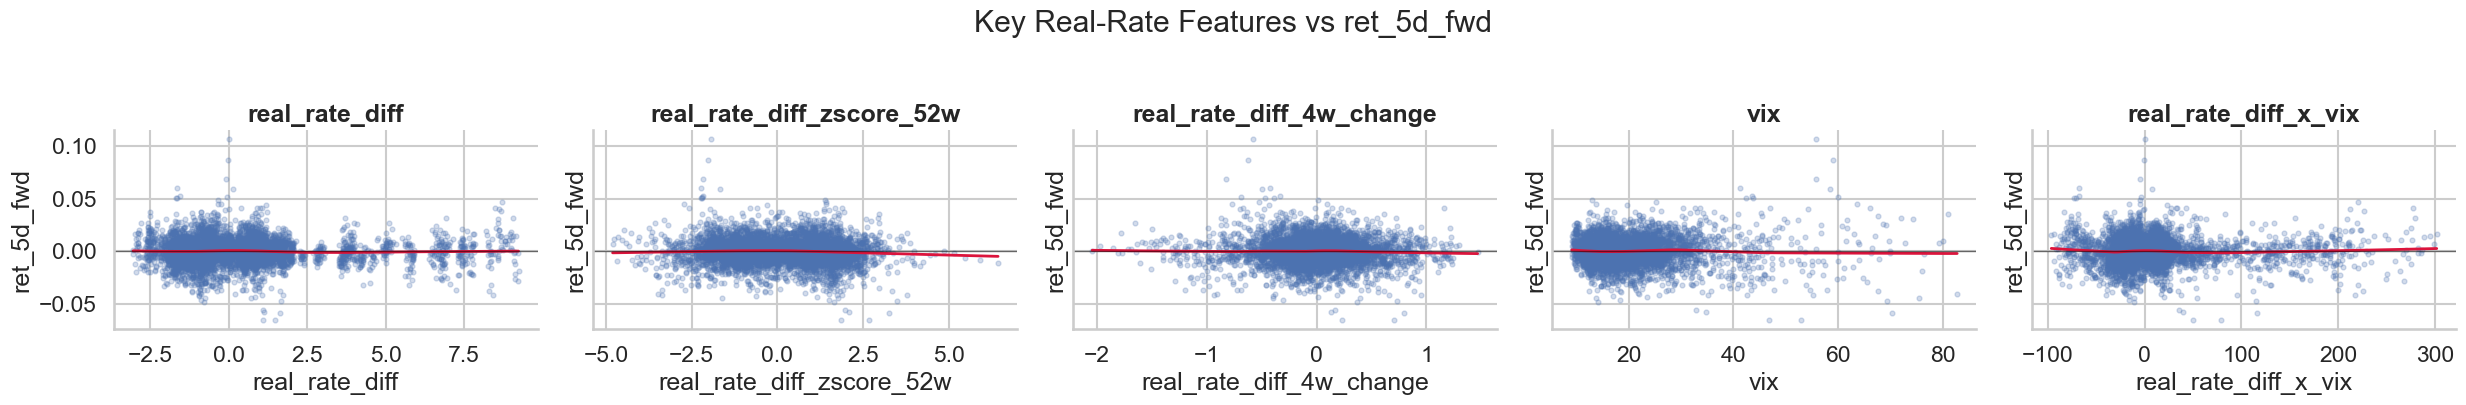

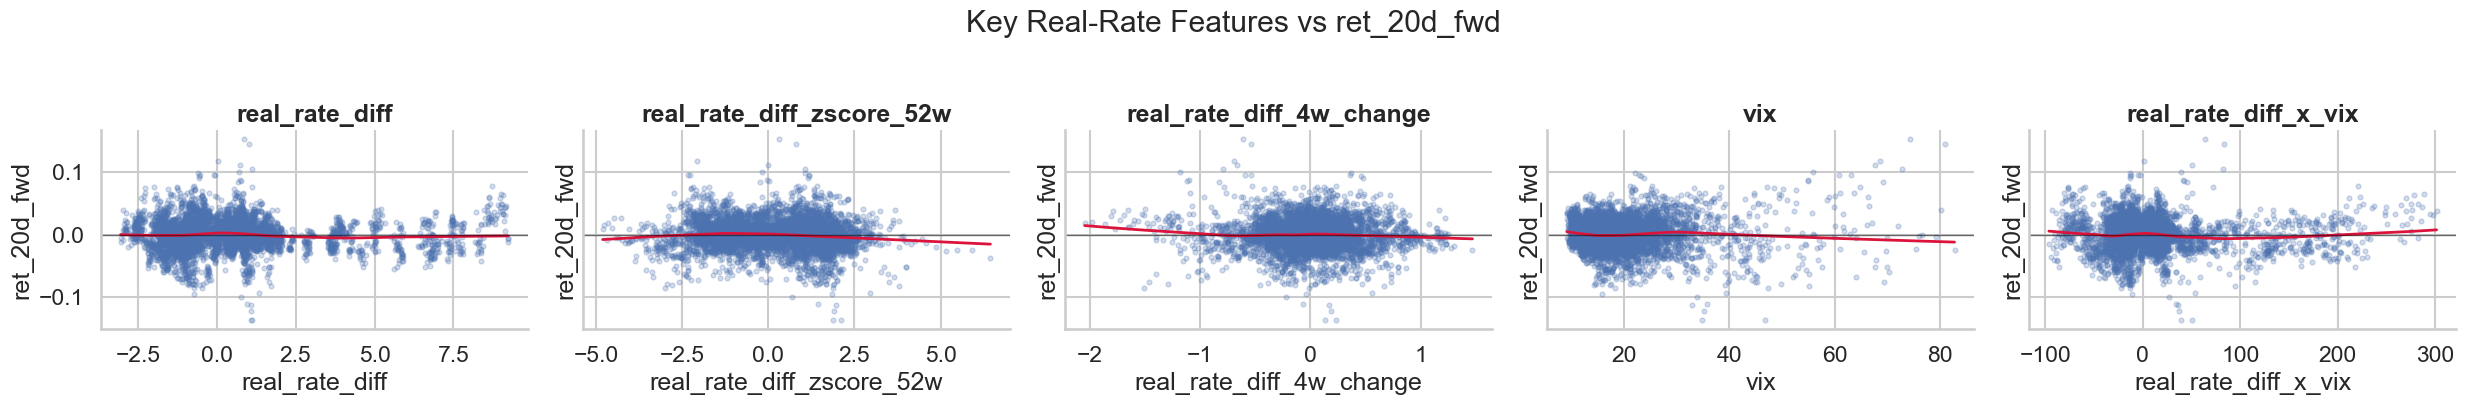

In [5]:
key_features = [
    "real_rate_diff",
    "real_rate_diff_zscore_52w",
    "real_rate_diff_4w_change",
    "vix",
    "real_rate_diff_x_vix",
]

for target in TARGET_COLS:
    fig, axes = plt.subplots(1, len(key_features), figsize=(5 * len(key_features), 4), sharey=True)
    for ax, feature in zip(axes, key_features):
        sns.regplot(
            data=model_df,
            x=feature,
            y=target,
            lowess=True,
            scatter_kws={"s": 12, "alpha": 0.25},
            line_kws={"color": "crimson", "lw": 2},
            ax=ax,
        )
        ax.axhline(0, color="black", lw=1, alpha=0.5)
        ax.set_title(feature)
    fig.suptitle(f"Key Real-Rate Features vs {target}", y=1.03)
    plt.tight_layout()
    plt.show()

## 3. PySINDy Sparse Library Setup

Because the target is a future return, the notebook uses PySINDy's feature libraries and sparse optimizers directly. The initial library is `PolynomialLibrary(degree=2)`, then a small set of manually selected custom terms is appended. This keeps the candidate set interpretable while allowing state-dependent stress and z-score effects. Targets are modeled in percentage points so STLSQ thresholds of 0.05 to 0.20 are meaningful for financial returns.

In [6]:
def make_custom_terms(X_scaled: np.ndarray, feature_cols: list[str]) -> tuple[np.ndarray, list[str]]:
    """Selected nonlinear terms that encode real-rate regime and risk-stress interactions."""
    ix = {name: i for i, name in enumerate(feature_cols)}
    rr = X_scaled[:, ix["real_rate_diff"]]
    z52 = X_scaled[:, ix["real_rate_diff_zscore_52w"]]
    z156 = X_scaled[:, ix["real_rate_diff_zscore_156w"]]
    chg = X_scaled[:, ix["real_rate_diff_4w_change"]]
    vix = X_scaled[:, ix["vix"]]

    terms = np.column_stack([
        z52 * vix,
        z156 * vix,
        chg * vix,
        rr * np.maximum(vix, 0),
        z52 * z156,
    ])
    names = [
        "real_rate_diff_zscore_52w*vix",
        "real_rate_diff_zscore_156w*vix",
        "real_rate_diff_4w_change*vix",
        "real_rate_diff*max(vix,0)",
        "real_rate_diff_zscore_52w*real_rate_diff_zscore_156w",
    ]
    return terms, names


def build_library(X_scaled: np.ndarray, feature_cols: list[str], fit_library: bool = True, poly_library=None):
    """Build a compact candidate library: degree-2 polynomial terms plus selected custom terms."""
    if poly_library is None:
        poly_library = ps.PolynomialLibrary(degree=2, include_bias=True)
    theta_poly = poly_library.fit_transform(X_scaled) if fit_library else poly_library.transform(X_scaled)
    poly_names = poly_library.get_feature_names(feature_cols)
    theta_custom, custom_names = make_custom_terms(X_scaled, feature_cols)
    theta = np.column_stack([theta_poly, theta_custom])
    names = poly_names + custom_names
    return theta, names, poly_library


def train_test_split_time(data: pd.DataFrame, train_frac: float = 0.80):
    split_idx = int(len(data) * train_frac)
    train = data.iloc[:split_idx].copy()
    test = data.iloc[split_idx:].copy()
    return train, test


train_df, test_df = train_test_split_time(model_df, train_frac=0.80)
TARGET_SCALE = 100.0  # Fit equations in percentage points, not raw decimal returns.
x_scaler = StandardScaler().fit(train_df[FEATURE_COLS])
X_train = x_scaler.transform(train_df[FEATURE_COLS])
X_test = x_scaler.transform(test_df[FEATURE_COLS])

Theta_train, LIBRARY_NAMES, POLY_LIBRARY = build_library(X_train, FEATURE_COLS, fit_library=True)
Theta_test, _, _ = build_library(X_test, FEATURE_COLS, fit_library=False, poly_library=POLY_LIBRARY)

print(f"Train rows: {len(train_df):,} | Test rows: {len(test_df):,}")
print(f"Library size: {Theta_train.shape[1]} candidate terms")
display(pd.DataFrame({"term": LIBRARY_NAMES}).head(40))

Train rows: 4,112 | Test rows: 1,029
Library size: 33 candidate terms


,term
0,1
1,real_rate_diff
2,real_rate_diff_zscore_52w
3,real_rate_diff_zscore_156w
4,real_rate_diff_4w_change
5,vix
6,real_rate_diff_x_vix
7,real_rate_diff^2
8,real_rate_diff real_rate_diff_zscore_52w
9,real_rate_diff real_rate_diff_zscore_156w


## 4. Model Discovery for Each Horizon

The primary optimizer is STLSQ over a small threshold and ridge grid. SR3 is also tested. `ConstrainedSR3` is included conditionally because some current PySINDy releases no longer expose that class. For noisy financial targets, an ensemble STLSQ model is estimated using bootstrap bagging.

In [1]:
def make_optimizer_specs(verbose: bool = True) -> dict[str, object]:
    specs: dict[str, object] = {}
    for threshold in [0.05, 0.10, 0.20]:
        for alpha in [0.1, 0.5, 1, 10, 100]:
            name = f"STLSQ_thr={threshold:.2f}_alpha={alpha:.2f}"
            specs[name] = ps.STLSQ(threshold=threshold, alpha=alpha, unbias=True, normalize_columns=True)

    for reg_weight in [0.005, 0.01, 0.05]:
        name = f"SR3_lam={reg_weight:.3f}"
        specs[name] = ps.SR3(reg_weight_lam=reg_weight, regularizer="L0", unbias=True, normalize_columns=True)

    constrained_sr3 = getattr(ps, "ConstrainedSR3", None)
    if constrained_sr3 is not None:
        try:
            specs["ConstrainedSR3_default"] = constrained_sr3(reg_weight_lam=0.01, unbias=True, normalize_columns=True)
        except TypeError as exc:
            if verbose:
                print(f"ConstrainedSR3 exists but needs explicit constraint arguments: {exc}")
    else:
        if verbose:
            print("ConstrainedSR3 is not exposed by this PySINDy version; skipping that optimizer.")

    specs["Ensemble_STLSQ"] = ps.EnsembleOptimizer(
        ps.STLSQ(threshold=0.10, alpha=0.05, unbias=True, normalize_columns=True),
        bagging=True,
        n_models=100,
        n_subset=int(0.75 * len(train_df)),
        replace=True,
        ensemble_aggregator=np.median,
    )
    return specs


def clone_optimizer(name: str):
    return make_optimizer_specs(verbose=False)[name]


def coef_from_optimizer(opt) -> np.ndarray:
    # PySINDy 2.1.0 exposes EnsembleOptimizer.coef_ as a scalar when a custom
    # aggregator is used, but keeps the fitted model coefficients in coef_list.
    coef_list = getattr(opt, "coef_list", None)
    if coef_list is not None and len(coef_list) > 0:
        coef_stack = np.asarray(coef_list, dtype=float)
        return np.median(coef_stack, axis=0).reshape(-1)

    coef = getattr(opt, "coef_", None)
    if coef is None:
        raise AttributeError("Optimizer did not expose coef_ after fit.")
    return np.asarray(coef).reshape(-1)


def fit_optimizer(opt, theta_train: np.ndarray, y_train: np.ndarray):
    opt.fit(theta_train, y_train.reshape(-1, 1))
    return opt


def predict_with_coef(theta: np.ndarray, coef: np.ndarray) -> np.ndarray:
    return theta @ coef


def model_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "r2": r2_score(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "directional_acc": float((np.sign(y_true) == np.sign(y_pred)).mean()),
    }


def sparsity_count(coef: np.ndarray, tol: float = 1e-10) -> int:
    return int(np.sum(np.abs(coef) > tol))


def format_equation(target: str, coef: np.ndarray, names: list[str], max_terms: int = 8, tol: float = 1e-10) -> str:
    active = [(name, value) for name, value in zip(names, coef) if abs(value) > tol]
    active = sorted(active, key=lambda item: abs(item[1]), reverse=True)[:max_terms]
    if not active:
        return f"{target} (%) ~ 0"
    rhs = ""
    for i, (name, value) in enumerate(active):
        sign = " + " if value >= 0 else " - "
        term = f"{abs(value):.4g}*{name}"
        rhs += ("" if i == 0 and value >= 0 else "-" if i == 0 else sign) + term
    return f"{target} (%) ~ {rhs}"


def coefficient_table(coef: np.ndarray, names: list[str], tol: float = 1e-10) -> pd.DataFrame:
    table = pd.DataFrame({"term": names, "coef": coef})
    table = table.loc[table["coef"].abs() > tol].copy()
    table["abs_coef"] = table["coef"].abs()
    return table.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")

NameError: name 'np' is not defined

In [ ]:
all_results = []
best_models = {}

for target in TARGET_COLS:
    y_train = train_df[target].to_numpy() * TARGET_SCALE
    y_test = test_df[target].to_numpy() * TARGET_SCALE
    target_results = []

    for name, opt in make_optimizer_specs().items():
        try:
            fitted = fit_optimizer(opt, Theta_train, y_train)
            coef = coef_from_optimizer(fitted)
            train_pred = predict_with_coef(Theta_train, coef)
            test_pred = predict_with_coef(Theta_test, coef)
            train_metrics = model_metrics(y_train, train_pred)
            test_metrics = model_metrics(y_test, test_pred)
            row = {
                "target": target,
                "model": name,
                "n_terms": sparsity_count(coef),
                "train_r2": train_metrics["r2"],
                "test_r2": test_metrics["r2"],
                "test_rmse": test_metrics["rmse"],
                "test_mae": test_metrics["mae"],
                "test_directional_acc": test_metrics["directional_acc"],
            }
            all_results.append(row)
            target_results.append((row, coef, fitted))
        except Exception as exc:
            print(f"{target} | {name} failed: {exc}")

    # Prefer sparse, non-degenerate models. R2 is a tie-breaker, not the sole objective.
    valid = [item for item in target_results if item[0]["n_terms"] > 0]
    best_row, best_coef, best_fit = sorted(
        valid,
        key=lambda item: (item[0]["test_r2"] - 0.002 * item[0]["n_terms"], -item[0]["test_rmse"]),
        reverse=True,
    )[0]
    best_models[target] = {"summary": best_row, "coef": best_coef, "optimizer": best_fit}

results_df = pd.DataFrame(all_results).sort_values(["target", "test_r2"], ascending=[True, False])
display(results_df.style.format({
    "train_r2": "{:.4f}",
    "test_r2": "{:.4f}",
    "test_rmse": "{:.5f}",
    "test_mae": "{:.5f}",
    "test_directional_acc": "{:.3f}",
}))

In [ ]:
for target, model_info in best_models.items():
    print("=" * 100)
    print(f"Best sparse model for {target}: {model_info['summary']['model']}")
    print(format_equation(target, model_info["coef"], LIBRARY_NAMES, max_terms=10))
    display(coefficient_table(model_info["coef"], LIBRARY_NAMES).head(15))

## 5. Model Comparison Across Horizons

The table compares sparse discovery results across 1-day, 5-day, and 20-day forward returns. Longer horizons often show clearer macro signal because daily FX returns are dominated by microstructure noise and event risk.

In [ ]:
best_summary = pd.DataFrame([info["summary"] for info in best_models.values()])
display(best_summary.style.format({
    "train_r2": "{:.4f}",
    "test_r2": "{:.4f}",
    "test_rmse": "{:.5f}",
    "test_mae": "{:.5f}",
    "test_directional_acc": "{:.3f}",
}))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ["test_r2", "test_directional_acc", "n_terms"]):
    sns.barplot(data=best_summary, x="target", y=metric, ax=ax, color="steelblue")
    ax.set_title(metric)
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 6. Hold-Out Simulation / Prediction

This section applies each discovered equation to the hold-out period only. The plots are not a trading strategy backtest; they show whether the discovered real-rate equation has stable explanatory direction and magnitude out of sample.

In [ ]:
predictions = pd.DataFrame(index=test_df.index)
for target, model_info in best_models.items():
    predictions[f"{target}_actual"] = test_df[target] * TARGET_SCALE
    predictions[f"{target}_pred"] = predict_with_coef(Theta_test, model_info["coef"])

for target in TARGET_COLS:
    actual_col = f"{target}_actual"
    pred_col = f"{target}_pred"
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    predictions[[actual_col, pred_col]].plot(ax=axes[0], lw=1.4)
    axes[0].axhline(0, color="black", lw=1, alpha=0.5)
    axes[0].set_title(f"Hold-Out Actual vs PySINDy Prediction: {target}")
    cumulative = predictions[[actual_col, pred_col]].cumsum()
    cumulative.plot(ax=axes[1], lw=1.4)
    axes[1].axhline(0, color="black", lw=1, alpha=0.5)
    axes[1].set_title("Cumulative Sum of Realized and Predicted Returns")
    plt.tight_layout()
    plt.show()

    sns.scatterplot(data=predictions, x=pred_col, y=actual_col, alpha=0.45, s=25)
    plt.axhline(0, color="black", lw=1, alpha=0.5)
    plt.axvline(0, color="black", lw=1, alpha=0.5)
    plt.title(f"Hold-Out Prediction Scatter: {target}")
    plt.tight_layout()
    plt.show()

## 7. Robustness and Diagnostics

Financial return models are noisy and often unstable. The bootstrap below repeatedly resamples the training set, refits the selected sparse optimizer, and measures how often each library term is selected. Terms that appear consistently are more credible than one-off in-sample artifacts.

In [ ]:
def bootstrap_stability(
    target: str,
    optimizer_name: str,
    theta_train: np.ndarray,
    y_train: np.ndarray,
    names: list[str],
    n_boot: int = 200,
    sample_frac: float = 0.75,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    n = len(y_train)
    sample_n = int(sample_frac * n)
    coefs = []
    for _ in range(n_boot):
        idx = rng.choice(n, size=sample_n, replace=True)
        opt = clone_optimizer(optimizer_name)
        try:
            fit_optimizer(opt, theta_train[idx], y_train[idx])
            coefs.append(coef_from_optimizer(opt))
        except Exception:
            continue

    coef_mat = np.vstack(coefs)
    stability = pd.DataFrame({
        "target": target,
        "term": names,
        "selection_freq": (np.abs(coef_mat) > 1e-10).mean(axis=0),
        "coef_median": np.median(coef_mat, axis=0),
        "coef_p10": np.quantile(coef_mat, 0.10, axis=0),
        "coef_p90": np.quantile(coef_mat, 0.90, axis=0),
    })
    stability["abs_coef_median"] = stability["coef_median"].abs()
    return stability.sort_values(["selection_freq", "abs_coef_median"], ascending=False).drop(columns="abs_coef_median")


stability_tables = {}
for target, model_info in best_models.items():
    stability = bootstrap_stability(
        target=target,
        optimizer_name=model_info["summary"]["model"],
        theta_train=Theta_train,
        y_train=train_df[target].to_numpy() * TARGET_SCALE,
        names=LIBRARY_NAMES,
        n_boot=200,
    )
    stability_tables[target] = stability
    print("=" * 100)
    print(f"Bootstrap coefficient stability: {target}")
    display(stability.head(15).style.format({
        "selection_freq": "{:.2f}",
        "coef_median": "{:.4g}",
        "coef_p10": "{:.4g}",
        "coef_p90": "{:.4g}",
    }))

In [ ]:
for target, stability in stability_tables.items():
    top = stability.head(12).iloc[::-1]
    plt.figure(figsize=(12, 7))
    plt.barh(top["term"], top["selection_freq"], color="slateblue", alpha=0.8)
    plt.xlim(0, 1)
    plt.title(f"Bootstrap Selection Frequency: {target}")
    plt.xlabel("Selection frequency")
    plt.tight_layout()
    plt.show()

residuals = pd.DataFrame(index=test_df.index)
for target in TARGET_COLS:
    residuals[target] = predictions[f"{target}_actual"] - predictions[f"{target}_pred"]

fig, axes = plt.subplots(len(TARGET_COLS), 2, figsize=(15, 4 * len(TARGET_COLS)))
for i, target in enumerate(TARGET_COLS):
    sns.histplot(residuals[target], kde=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"Hold-Out Residual Distribution: {target}")
    sm.graphics.tsa.plot_acf(residuals[target].dropna(), lags=30, ax=axes[i, 1])
    axes[i, 1].set_title(f"Hold-Out Residual ACF: {target}")
plt.tight_layout()
plt.show()

## 8. Optional Feature Smoothing

This optional check smooths the state variables with short moving averages before rebuilding the library. The target remains unsmoothed. If the smoothed equations materially change the signs of the dominant terms, the real-rate relationship should be interpreted cautiously.

In [ ]:
SMOOTH_FEATURES = False
SMOOTH_WINDOW = 5

if SMOOTH_FEATURES:
    smoothed_df = model_df.copy()
    smoothed_df[FEATURE_COLS] = smoothed_df[FEATURE_COLS].rolling(SMOOTH_WINDOW, min_periods=1).mean()
    sm_train_df, sm_test_df = train_test_split_time(smoothed_df, train_frac=0.80)
    sm_scaler = StandardScaler().fit(sm_train_df[FEATURE_COLS])
    sm_X_train = sm_scaler.transform(sm_train_df[FEATURE_COLS])
    sm_X_test = sm_scaler.transform(sm_test_df[FEATURE_COLS])
    sm_Theta_train, sm_names, sm_poly = build_library(sm_X_train, FEATURE_COLS, fit_library=True)
    sm_Theta_test, _, _ = build_library(sm_X_test, FEATURE_COLS, fit_library=False, poly_library=sm_poly)

    sm_rows = []
    for target in TARGET_COLS:
        opt = ps.EnsembleOptimizer(
            ps.STLSQ(threshold=0.10, alpha=0.05, unbias=True, normalize_columns=True),
            bagging=True,
            n_models=100,
            n_subset=int(0.75 * len(sm_train_df)),
            replace=True,
            ensemble_aggregator=np.median,
        )
        fit_optimizer(opt, sm_Theta_train, sm_train_df[target].to_numpy() * TARGET_SCALE)
        coef = coef_from_optimizer(opt)
        pred = predict_with_coef(sm_Theta_test, coef)
        metrics = model_metrics(sm_test_df[target].to_numpy() * TARGET_SCALE, pred)
        sm_rows.append({"target": target, "n_terms": sparsity_count(coef), **metrics})
        print(format_equation(target, coef, sm_names, max_terms=10))

    display(pd.DataFrame(sm_rows))
else:
    print("Feature smoothing check is disabled. Set SMOOTH_FEATURES=True to run it.")

## 9. Economic Interpretation

Use the discovered equations as a disciplined summary of the real-rate channel, not as structural proof.

- A positive coefficient on `real_rate_diff` or its z-scores means wider US real-rate advantage is associated with higher future EURUSD returns under the notebook's return convention. If EURUSD is quoted as USD per EUR, that sign should be reconciled carefully with the expected dollar-support channel.
- A negative coefficient on `real_rate_diff` or its z-scores is more consistent with the classic capital-flow view: higher US real yields attract capital toward USD assets, weighing on EURUSD.
- `real_rate_diff_4w_change` captures whether recent real-rate momentum matters beyond the level. A negative coefficient implies faster widening in favor of the US precedes EURUSD weakness; a positive coefficient suggests overshoot or delayed repricing.
- `vix` and real-rate/VIX interaction terms test whether risk stress changes the real-rate transmission mechanism. In high-volatility regimes, safe-haven dollar demand can amplify or dominate yield-spread effects.
- Stable terms across bootstrap samples deserve more weight than terms selected once by a single sparse fit. In macro-FX, sparse stability is usually more informative than marginal changes in R-squared.

Final conclusion template after running the notebook: identify the horizon with the sparsest stable equation, report the dominant signed terms, and explain whether the equations support a real-rate capital-flow channel, a risk-stress interaction channel, or weak/no robust relationship.